In [1]:
('Task 2 :- Iris Flower Classification')

'Task 2 :- Iris Flower Classification'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

data = pd.read_csv("IRIS.csv")

data.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


In [3]:
data.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
data.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [15]:
from sklearn.preprocessing import LabelEncoder
from pandas.core.dtypes.common import is_numeric_dtype
le = LabelEncoder()

In [16]:
for i in data.columns:
    if is_numeric_dtype(data[i]):
        continue
    else:
        data[i] = le.fit_transform(data[i])

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


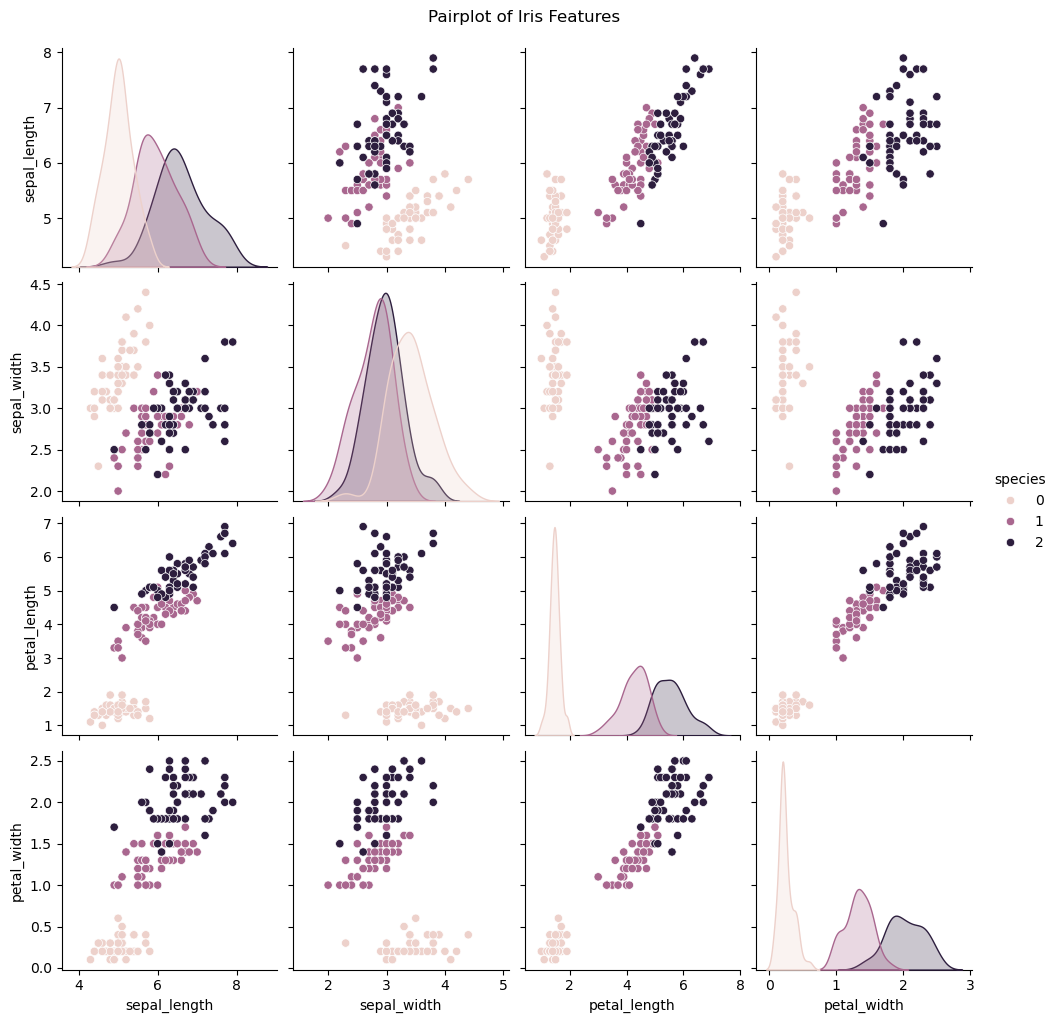

In [18]:
sns.pairplot(data,hue = 'species')
plt.suptitle("Pairplot of Iris Features", y =1.02)
plt.show()

C:\Users\MADHURA\AppData\Local\Temp\ipykernel_12908\2973125037.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = "species", data = data, palette = "Set2")


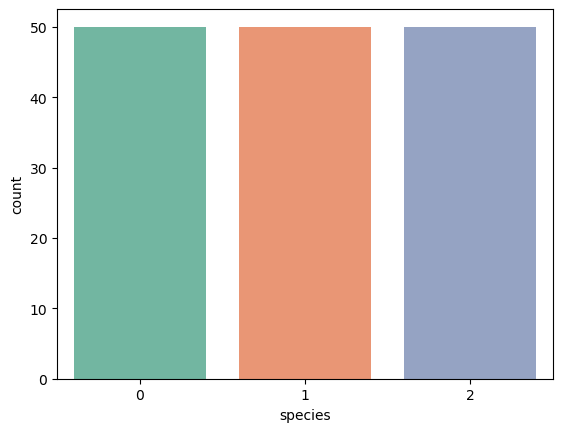

In [19]:
sns.countplot(x = "species", data = data, palette = "Set2")
plt.show()

<Axes: xlabel='sepal_width', ylabel='Count'>

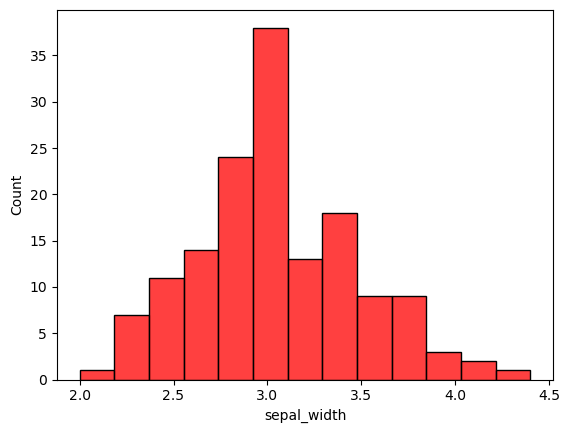

In [20]:
sns.histplot(x = data.sepal_width, data = data, color = 'red')

<Axes: xlabel='petal_length', ylabel='Count'>

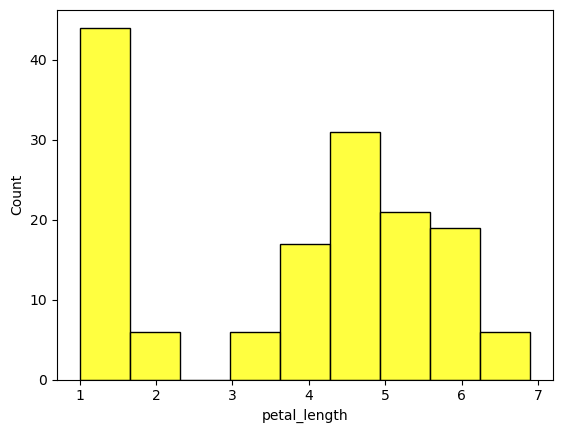

In [21]:
sns.histplot(x = data.petal_length, data = data, color = 'yellow')

<Axes: xlabel='petal_width', ylabel='Count'>

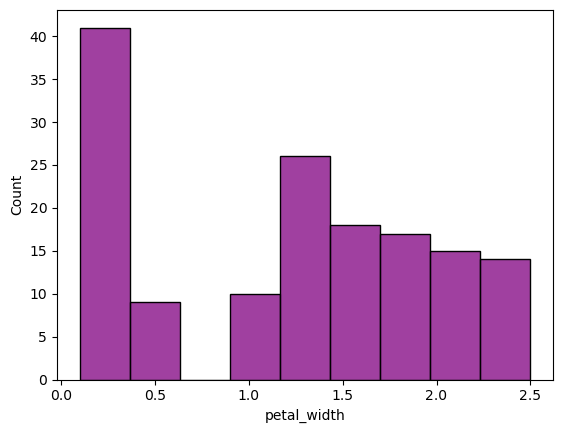

In [22]:
sns.histplot(x = data.petal_width, data = data, color = 'purple')

<Axes: >

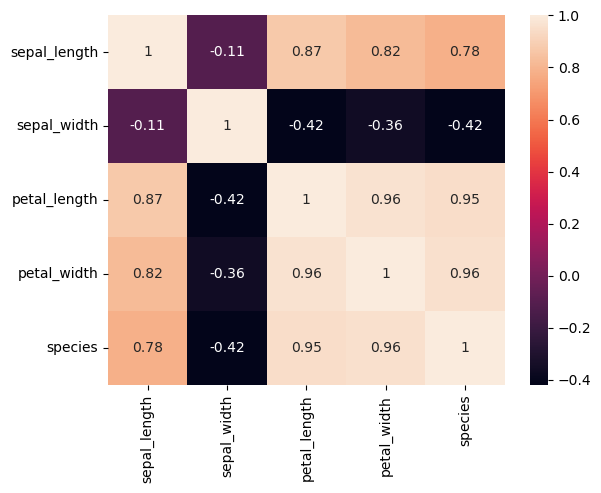

In [23]:
corr = data.corr()
sns.heatmap(corr, annot = True)

In [26]:
data.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [25]:
x = data.drop(['species'], axis = 1)
y = data.species
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3)

In [27]:
model = LogisticRegression()
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [28]:
print("Score of Train data:", model.score(x_train, y_train))
print("Score of Test data:", model.score(x_test, y_test))

Score of Train data: 0.9904761904761905
Score of Test data: 0.9333333333333333


In [30]:
from sklearn.ensemble import RandomForestClassifier
model_2 = RandomForestClassifier(n_estimators = 300, random_state = 100)
model_2.fit(x_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
print("Score of Train data:", model_2.score(x_train, y_train))
print("Score of Test data:", model_2.score(x_test, y_test))

Score of Train data: 1.0
Score of Test data: 0.9333333333333333


In [32]:
model_3 = KNeighborsClassifier()
model_3.fit(x_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [33]:
print("Score of train data:", model_3.score(x_train, y_train))
print("Score of test data:", model_3.score(x_test, y_test))

Score of train data: 0.9904761904761905
Score of test data: 0.9555555555555556


In [34]:
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [35]:
data_2 = {"sepal_length":[5.2], "sepal_width":[3.6], "petal_length":[1.4], "petal_width":[0.2]}
trail = pd.DataFrame(data_2)
result = model.predict(trail)
print("Result Species:", result[0])

Result Species: 0


In [36]:
y_pred = model.predict(x_test)
print(y_pred[:10])

[1 0 2 0 1 2 1 0 0 1]


In [37]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9333333333333333
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.94      0.88      0.91        17
           2       0.87      0.93      0.90        14

    accuracy                           0.93        45
   macro avg       0.93      0.94      0.94        45
weighted avg       0.93      0.93      0.93        45



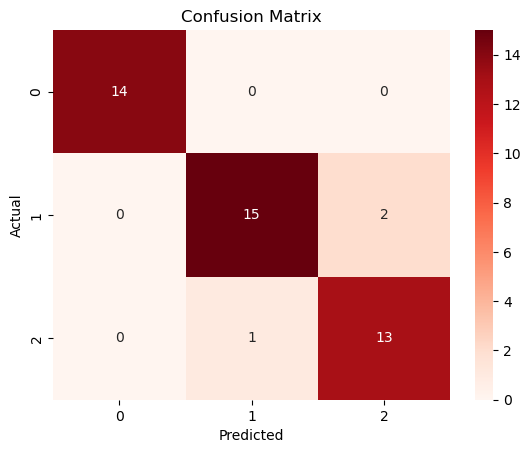

In [38]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap='Reds')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
